## test optimize

In [1]:
# setup imports
import sys
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
PROJECT_ROOT = Path().resolve().parents[2]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

In [2]:
from src.models import *
from src.forcing import load_lumped_forcing
from src.paths import *
from ewatercycle.observation.grdc import get_grdc_data

from scipy.optimize import minimize
import numpy as np

import cma

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


In [3]:
ERA5_forcing_loaded = load_lumped_forcing("Kerki_GRDC", "ERA5", "1959-1963")
#plot_ERA5_forcing(ERA5_forcing_loaded)

In [4]:
theta_test = np.mean(generate_HBV_parameters(100), axis=0)

grdc_station = get_grdc_data(2617110,
                   '1959-01-02T00:00Z',
                   '1963-12-31T00:00Z',
                   data_home=GRDC/'Daily')
                   
q_obs = grdc_station['streamflow']
years = q_obs['time'].dt.year.values
shape_name="Kerki_GRDC"

In [5]:
J = objective(
    theta_test,
    forcing=ERA5_forcing_loaded,
    q_obs=q_obs,
    years=years,
    shape_name=shape_name,
)

print("Objective value:", J)

Objective value: 3.8107099453204842


In [6]:
grdc_station = get_grdc_data(2617110,
                   '1959-01-01T00:00Z',
                   '1963-12-31T00:00Z',
                   data_home=GRDC/'Daily')
                   
obs = grdc_station['streamflow']

In [7]:
# J_val = float(J)   # converts xarray.DataArray to a plain Python float
# print("Objective value:", J_val)

In [8]:
# # run safe test with maxfun=5
# res = minimize(
#     objective_safe,
#     x0=theta_test,
#     args=(ERA5_forcing_loaded, q_obs.values, years, shape_name),
#     method="Powell",
#     bounds=bounds,
#     options={"maxiter": 5, "disp": True}
# )

# print("Test run completed")
# print("Best theta found (approx):", res.x)
# print("Objective value:", res.fun)

In [9]:
# x0_norm = scale(0.5 * (p_min + p_max))  # middle of normalized range

# res = cma.fmin(
#     objective_safe,
#     x0_norm,
#     sigma0=0.1,
#     args=(ERA5_forcing_loaded, q_obs.values, years, shape_name),
#     options={
#         'bounds': [np.zeros_like(p_min).tolist(), np.ones_like(p_max).tolist()],
#         'popsize': 5,
#         'maxfevals': 30
#     }
# )

In [10]:
# CMA-ES test setup
x0_norm = scale(0.5 * (p_min + p_max))  # start in the middle
sigma0 = 0.1  # step size in normalized space

res = cma.fmin(
    objective_safe,
    x0_norm,
    sigma0,
    args=(ERA5_forcing_loaded, q_obs.values, years, shape_name),
    options={
        'bounds': [np.zeros_like(p_min).tolist(), np.ones_like(p_max).tolist()],
        'popsize': 10,
        'maxfevals': 1000
    }
)

(5_w,10)-aCMA-ES (mu_w=3.2,w_1=45%) in dimension 9 (seed=131960, Thu Jan 22 08:36:19 2026)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     10 5.250511170420188e-01 1.0e+00 1.08e-01  1e-01  1e-01 0:59.5
    2     20 4.733373542648228e-01 1.3e+00 1.23e-01  1e-01  1e-01 2:02.1
    3     30 3.964418206210172e-01 1.3e+00 1.36e-01  1e-01  2e-01 3:01.0
    4     40 4.040114831002857e-01 1.3e+00 1.41e-01  1e-01  2e-01 4:01.5
    5     50 3.542418059048564e-01 1.4e+00 1.43e-01  1e-01  2e-01 5:02.9
    6     60 3.755645014001637e-01 1.5e+00 1.35e-01  1e-01  2e-01 6:01.2
    7     70 3.859440790853177e-01 1.5e+00 1.26e-01  1e-01  1e-01 7:00.9
    8     80 3.880853959176248e-01 1.5e+00 1.19e-01  1e-01  1e-01 7:58.4
    9     90 3.836284511231915e-01 1.6e+00 1.07e-01  9e-02  1e-01 8:57.1
   10    100 3.637691530264456e-01 1.6e+00 1.01e-01  8e-02  1e-01 9:57.4
   11    110 3.696783079317949e-01 1.5e+00 8.97e-02  7e-02  1e-01 10:56.2
   12    120 3.685000949550084e-0

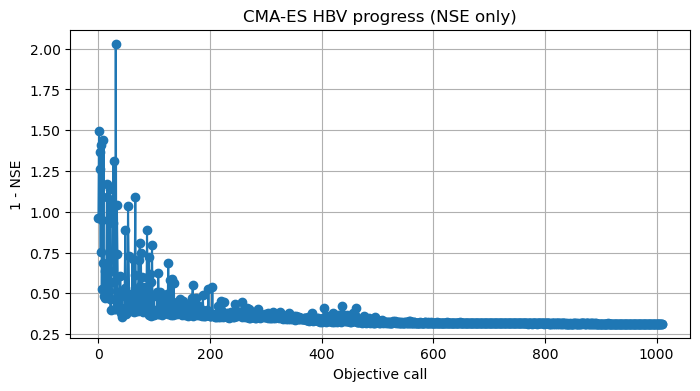

In [11]:
import pandas as pd
# convert history to DataFrame for analysis
history_df = pd.DataFrame({
    "objective": history["objective"],
    **{f"theta_{i}": [th[i] for th in history["theta_phys"]] for i in range(len(p_min))}
})

# quick plot example
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(history_df["objective"], marker='o')
plt.xlabel("Objective call")
plt.ylabel("1 - NSE")
plt.title("CMA-ES HBV progress (NSE only)")
plt.grid(True)
plt.show()

# # parameter scatter plot example
# plt.figure(figsize=(10,5))
# for i in range(len(p_min)):
#     plt.plot(history_df[f"theta_{i}"], label=f"param_{i}")
# plt.xlabel("Objective call")
# plt.ylabel("Parameter value")
# plt.title("HBV parameters during CMA-ES")
# plt.legend()
# plt.show()

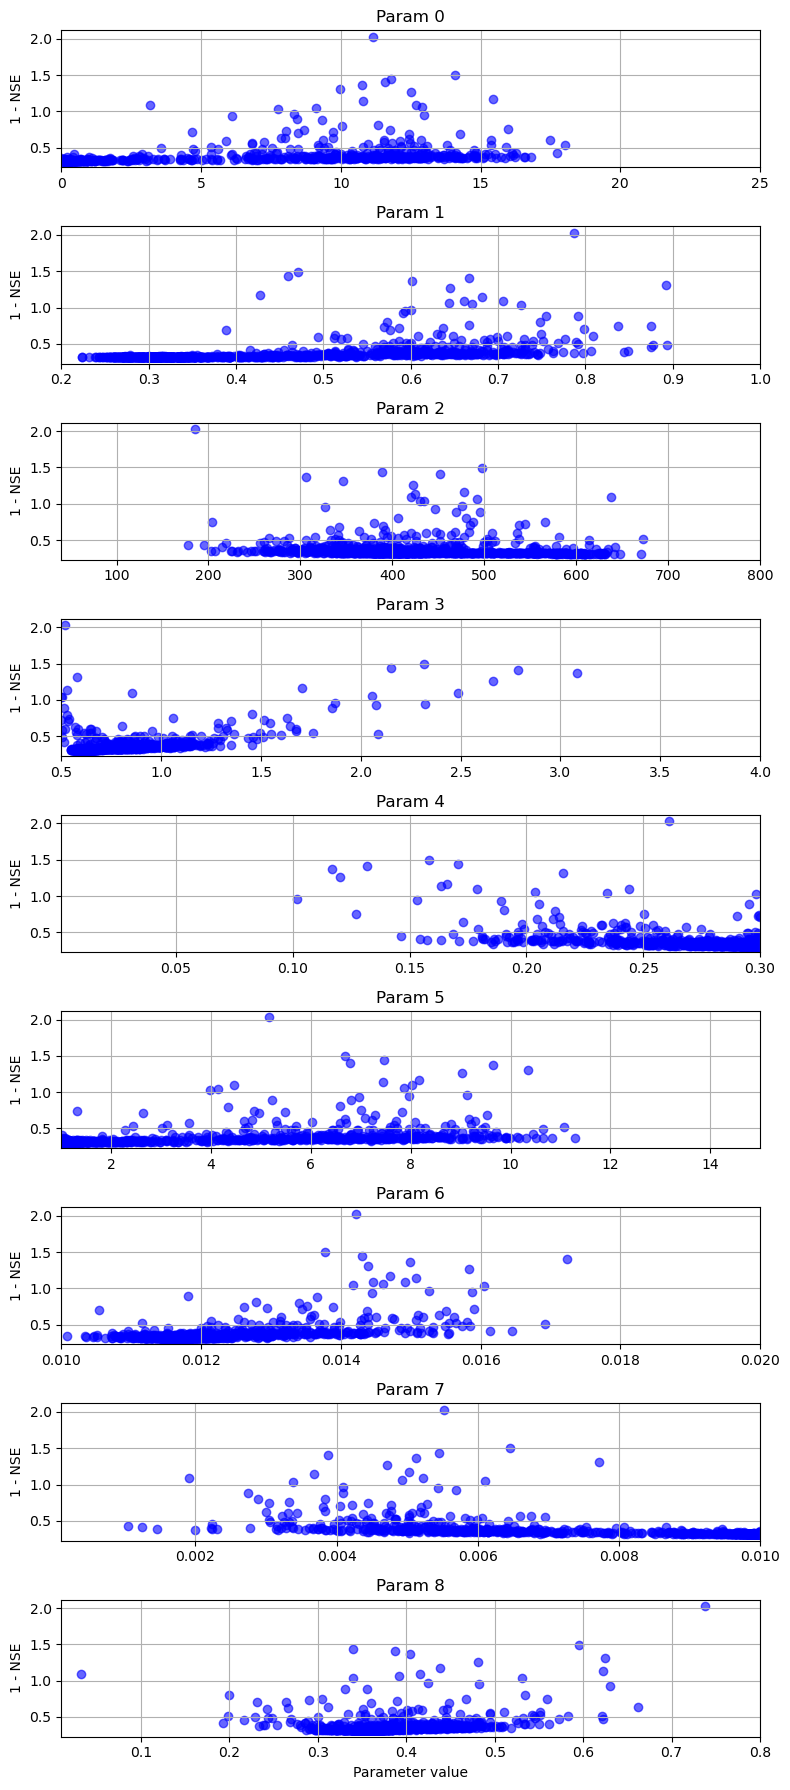

In [12]:
import matplotlib.pyplot as plt

n_params = len(p_min)
fig, axes = plt.subplots(n_params, 1, figsize=(8, 2*n_params), sharex=False)

for i in range(n_params):
    ax = axes[i]
    ax.scatter(history_df[f"theta_{i}"], history_df["objective"], c='blue', alpha=0.6)
    ax.set_ylabel("1 - NSE")
    ax.set_title(f"Param {i}")
    ax.set_xlim(p_min[i], p_max[i])  # set x-axis limits per parameter
    ax.grid(True)

axes[-1].set_xlabel("Parameter value")
plt.tight_layout()
plt.show()

In [13]:
x_norm = res[0]  # or res.x depending on your CMA-ES call

# convert back to physical parameter space
theta_phys = unscale(x_norm)

print("Physical HBV parameters:")
for i, th in enumerate(theta_phys):
    print(f"Param {i}: {th:.4f}")

Physical HBV parameters:
Param 0: 0.0015
Param 1: 0.2553
Param 2: 627.1571
Param 3: 0.5554
Param 4: 0.2996
Param 5: 1.0636
Param 6: 0.0118
Param 7: 0.0100
Param 8: 0.3573


In [14]:
import numpy as np

# normalized incumbent solution
x_norm = np.array(res[5])

# unscale to physical parameter values
theta_phys = unscale(x_norm)

# print nicely
for i, th in enumerate(theta_phys):
    print(f"Param {i}: {th:.4f}")

Param 0: 0.0015
Param 1: 0.2553
Param 2: 627.1571
Param 3: 0.5554
Param 4: 0.2996
Param 5: 1.0636
Param 6: 0.0118
Param 7: 0.0100
Param 8: 0.3573
